# Lista 2 - Regressão Logística e Métodos Estatísticos
---
- **Aluno:** Diego Melo do Nascimento  
- **Matrícula:** 603127
- **Disciplina:** Aprendizagem de Máquina (2026.1)
- **Professor:** César Lincoln Cavalcante Mattos

## Descrição

Este notebook implementa do zero os classificadores solicitados e avalia em validação cruzada de 10 folds:

- **Questão 1** - `breastcancer.csv` (569 amostras, 30 atributos, binária)  
  Regressão Logística (GD), GDA, Naive Bayes Gaussiano
- **Questão 2** - `vehicle.csv` (846 amostras, 18 atributos, 4 classes)  
  Regressão Softmax (GD), GDA, Naive Bayes Gaussiano

Para cada modelo reportamos média e desvio padrão da acurácia global e por classe.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from warnings import filterwarnings

filterwarnings("ignore")
np.random.seed(42)

## Funções Auxiliares

Implementação manual das funções de pré-processamento (média, desvio, normalização Z-score), ativações (`sigmoid`, `softmax`), codificação `one_hot` e métricas (acurácia, matriz de confusão). A normalização é feita dentro do k-fold (fit no treino, aplica no teste).

In [2]:
def compute_mean(X):
    return np.sum(X, axis=0) / X.shape[0]

def compute_std(X):
    mu = compute_mean(X)
    return np.sqrt(np.sum((X - mu) ** 2, axis=0) / X.shape[0])

def fit_standardize(X):
    mu = compute_mean(X)
    sigma = compute_std(X)
    sigma[sigma == 0] = 1
    return mu, sigma

def apply_standardize(X, mu, sigma):
    return (X - mu) / sigma

def add_bias(X):
    return np.c_[np.ones((X.shape[0], 1)), X]

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def softmax(z):
    z_max = np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z - z_max)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def one_hot(y, num_classes):
    Y = np.zeros((y.shape[0], num_classes))
    for i in range(y.shape[0]):
        Y[i, int(y[i])] = 1
    return Y

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def accuracy_per_class(y_true, y_pred, classes):
    acc_dict = {}
    for c in classes:
        mask = y_true == c
        if mask.sum() > 0:
            acc_dict[c] = np.mean(y_pred[mask] == y_true[mask])
    return acc_dict

def confusion_matrix(y_true, y_pred, classes):
    cm = np.zeros((len(classes), len(classes)), dtype=int)
    class_to_idx = {c: i for i, c in enumerate(sorted(classes))}
    for t, p in zip(y_true, y_pred):
        cm[class_to_idx[t], class_to_idx[p]] += 1
    return cm

## Modelos de Classificação

Implementação dos 4 classificadores do zero, conforme as fórmulas apresentadas no material da disciplina.

### Regressão Logística (GD)

Regra de atualização do Gradiente Descendente:

$$w(t) = w(t-1) + \alpha \cdot \frac{1}{N} \sum_{i=1}^{N} e_i(t-1) \cdot x_i \quad , \quad e_i = y_i - \sigma(w^\top x_i)$$

In [3]:
def logistic_regression_gd(X, y, alpha=0.1, epochs=1000):
    X_b = add_bias(X)
    N, d = X_b.shape
    w = np.zeros(d)
    for _ in range(epochs):
        y_hat = sigmoid(X_b @ w)
        error = y - y_hat
        w = w + alpha * (X_b.T @ error) / N
    return w

def predict_logistic(X, w):
    proba = sigmoid(add_bias(X) @ w)
    return (proba >= 0.5).astype(int)

### Regressão Softmax (GD para múltiplas saídas)

Regra de atualização:

$$w_k(t) = w_k(t-1) + \alpha \cdot \frac{1}{N} \sum_{i=1}^{N} e_{ik}(t-1) \cdot x_i \quad , \quad e_{ik} = y_{ik} - \frac{\exp(w_k^\top x_i)}{\sum_{j=1}^{K} \exp(w_j^\top x_i)}$$

In [4]:
def softmax_regression_gd(X, y, num_classes, alpha=0.1, epochs=1000):
    X_b = add_bias(X)
    N, d = X_b.shape
    Y = one_hot(y, num_classes)
    W = np.zeros((d, num_classes))
    for _ in range(epochs):
        P = softmax(X_b @ W)
        error = Y - P
        W = W + alpha * (X_b.T @ error) / N
    return W

def predict_softmax(X, W):
    P = softmax(add_bias(X) @ W)
    return np.argmax(P, axis=1)

### Análise do Discriminante Gaussiano (GDA)

Modelagem da verossimilhança via Gaussiana multivariada por classe:

$$\hat{y}_* = \arg\max_k \left[ \log p(C_k) - \tfrac{1}{2} \log |\Sigma_k| - \tfrac{1}{2} (x_* - \mu_k)^\top \Sigma_k^{-1} (x_* - \mu_k) \right]$$

In [5]:
def gaussian_discriminant(X, y):
    classes = np.unique(y)
    params = {}
    for c in classes:
        X_c = X[y == c]
        params[c] = {
            "pi": X_c.shape[0] / X.shape[0],
            "mu": compute_mean(X_c),
            "sigma": np.cov(X_c.T)
        }
    return params

def predict_gda(X, params):
    classes = sorted(list(params.keys()))
    scores = np.zeros((X.shape[0], len(classes)))
    for i, c in enumerate(classes):
        pi = params[c]["pi"]
        mu = params[c]["mu"]
        sigma = params[c]["sigma"] + np.eye(params[c]["sigma"].shape[0]) * 1e-6
        sign, logdet = np.linalg.slogdet(sigma)
        if sign <= 0:
            scores[:, i] = -np.inf
            continue
        sigma_inv = np.linalg.inv(sigma)
        diff = X - mu
        mahal = np.sum(diff @ sigma_inv * diff, axis=1)
        scores[:, i] = np.log(pi) - 0.5 * logdet - 0.5 * mahal
    return np.array([classes[idx] for idx in np.argmax(scores, axis=1)])

### Naive Bayes Gaussiano

Assume independência condicional entre atributos dado a classe:

$$\hat{y}_* = \arg\max_k \left[ \log p(C_k) - \tfrac{1}{2} \sum_{d=1}^{D} \log(2\pi\sigma_{dk}^2) - \tfrac{1}{2} \sum_{d=1}^{D} \frac{(x_{*d} - \mu_{dk})^2}{\sigma_{dk}^2} \right]$$

In [6]:
def naive_bayes_gaussian(X, y):
    classes = np.unique(y)
    params = {}
    for c in classes:
        X_c = X[y == c]
        params[c] = {
            "pi": X_c.shape[0] / X.shape[0],
            "mu": compute_mean(X_c),
            "var": np.var(X_c, axis=0)
        }
    return params

def predict_nb(X, params):
    classes = sorted(list(params.keys()))
    scores = np.zeros((X.shape[0], len(classes)))
    for i, c in enumerate(classes):
        pi = params[c]["pi"]
        mu = params[c]["mu"]
        var = np.maximum(params[c]["var"], 1e-10)
        scores[:, i] = np.log(pi) - 0.5 * np.sum(np.log(2 * np.pi * var)) - 0.5 * np.sum(((X - mu) ** 2) / var, axis=1)
    return np.array([classes[idx] for idx in np.argmax(scores, axis=1)])

## Validação Cruzada (10-Fold)

Divisão aleatória dos dados em 10 folds. Em cada iteração:
1. 9 folds são usados para treino e 1 para teste.
2. A normalização (Z-score) é ajustada **apenas** no treino e aplicada também no teste (evita data leakage).
3. O modelo é treinado e avaliado.

Ao final reportamos média e desvio padrão da acurácia global e por classe.

In [7]:
def kfold_split(n_samples, k=10):
    indices = np.random.permutation(n_samples)
    test_folds = np.array_split(indices, k)
    folds = []
    for i in range(k):
        test_idx = test_folds[i]
        train_idx = np.concatenate([test_folds[j] for j in range(k) if j != i])
        folds.append((train_idx, test_idx))
    return folds

def evaluate_kfold(X, y, fit_func, predict_func, k=10):
    folds = kfold_split(X.shape[0], k)
    classes = np.unique(y)
    accs = []
    accs_class = {c: [] for c in classes}
    all_y_true = []
    all_y_pred = []
    for train_idx, test_idx in folds:
        X_train_raw, X_test_raw = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        mu, sigma = fit_standardize(X_train_raw)
        X_train = apply_standardize(X_train_raw, mu, sigma)
        X_test = apply_standardize(X_test_raw, mu, sigma)
        model = fit_func(X_train, y_train)
        y_pred = predict_func(X_test, model)
        accs.append(accuracy(y_test, y_pred))
        acc_c = accuracy_per_class(y_test, y_pred, classes)
        for c in classes:
            if c in acc_c:
                accs_class[c].append(acc_c[c])
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)
    return np.array(accs), accs_class, np.array(all_y_true), np.array(all_y_pred)

def print_summary(title, results):
    print(title)
    print("-" * 60)
    print(f"{'Modelo':<25}{'Acurácia Global':<22}")
    print("-" * 60)
    for name, (accs, accs_c) in results.items():
        print(f"{name:<25}{np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print()
    print(f"{'Modelo':<25}" + "".join([f"Classe {int(c)}".ljust(22) for c in sorted(list(results.values())[0][1].keys())]))
    print("-" * 60)
    for name, (accs, accs_c) in results.items():
        row = f"{name:<25}"
        for c in sorted(accs_c.keys()):
            vals = np.array(accs_c[c])
            row += f"{np.mean(vals):.4f} ± {np.std(vals):.4f}  "
        print(row)
    print()

def plot_cm(cm, classes, title, ax):
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    im = ax.imshow(cm_pct, cmap="Blues", vmin=0, vmax=100)
    ax.set_title(title)
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(sorted(classes))
    ax.set_yticklabels(sorted(classes))
    ax.set_xlabel("Predito")
    ax.set_ylabel("Verdadeiro")
    for i in range(len(classes)):
        for j in range(len(classes)):
            color = "white" if cm_pct[i, j] > 50 else "black"
            ax.text(j, i, f"{cm_pct[i, j]:.1f}%\n({cm[i, j]})", ha="center", va="center", color=color, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046)

## Questão 1 - Câncer de Mama (Classificação Binária)

**Dataset:** `breastcancer.csv` — 569 amostras, 30 atributos, 2 classes (0 = negativa, 1 = positiva).

Avaliação em validação cruzada (10 folds) dos classificadores binários:
- Regressão Logística (GD)
- Análise do Discriminante Gaussiano
- Naive Bayes Gaussiano

### Carregamento dos Dados

In [8]:
data = np.genfromtxt("./data/breastcancer.csv", delimiter=",")
X1 = data[:, :-1]
y1 = data[:, -1].astype(int)

print(f"Amostras: {X1.shape[0]} | Features: {X1.shape[1]}")
values, counts = np.unique(y1, return_counts=True)
for v, c in zip(values, counts):
    print(f"Classe {int(v)}: {int(c)} ({c / X1.shape[0] * 100:.1f}%)")

Amostras: 569 | Features: 30
Classe 0: 357 (62.7%)
Classe 1: 212 (37.3%)


### Treinamento e Avaliação (10-Fold CV)

In [9]:
np.random.seed(42)
accs_lr, accs_lr_c, yt_lr, yp_lr = evaluate_kfold(X1, y1, logistic_regression_gd, predict_logistic)
accs_gd1, accs_gd1_c, yt_gd1, yp_gd1 = evaluate_kfold(X1, y1, gaussian_discriminant, predict_gda)
accs_nb1, accs_nb1_c, yt_nb1, yp_nb1 = evaluate_kfold(X1, y1, naive_bayes_gaussian, predict_nb)

### Resultados: Acurácia Global e por Classe

In [10]:
results_q1 = {
    "Regressão Logística": (accs_lr, accs_lr_c),
    "GDA": (accs_gd1, accs_gd1_c),
    "Naive Bayes": (accs_nb1, accs_nb1_c)
}
print_summary("QUESTÃO 1 - CÂNCER DE MAMA", results_q1)

QUESTÃO 1 - CÂNCER DE MAMA
------------------------------------------------------------
Modelo                   Acurácia Global       
------------------------------------------------------------
Regressão Logística      0.9789 ± 0.0189
GDA                      0.9560 ± 0.0287
Naive Bayes              0.9332 ± 0.0321

Modelo                   Classe 0              Classe 1              
------------------------------------------------------------
Regressão Logística      0.9884 ± 0.0143  0.9653 ± 0.0398  
GDA                      0.9642 ± 0.0267  0.9416 ± 0.0404  
Naive Bayes              0.9559 ± 0.0442  0.8935 ± 0.0395  



### Comparação de Modelos

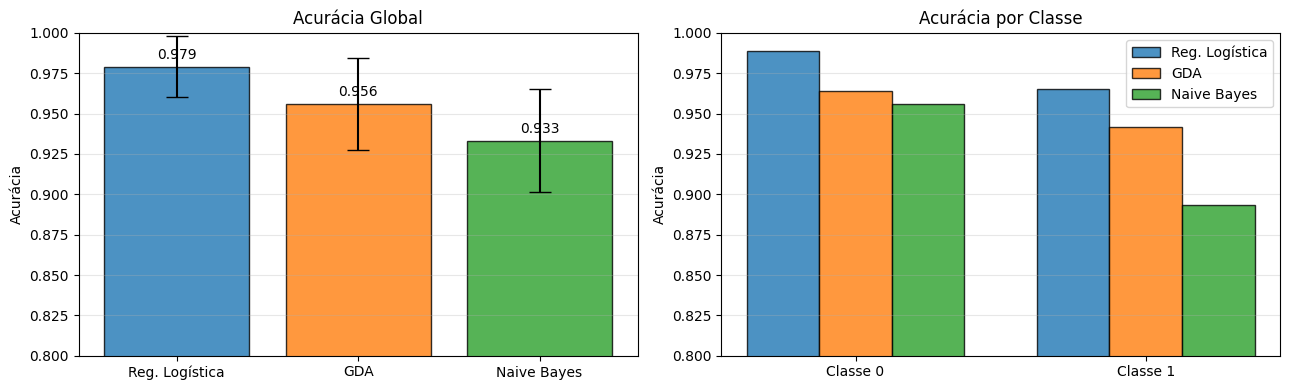

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
models = ["Reg. Logística", "GDA", "Naive Bayes"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
means = [np.mean(accs_lr), np.mean(accs_gd1), np.mean(accs_nb1)]
stds = [np.std(accs_lr), np.std(accs_gd1), np.std(accs_nb1)]

axes[0].bar(models, means, yerr=stds, capsize=8, color=colors, alpha=0.8, edgecolor="black")
axes[0].set_ylabel("Acurácia")
axes[0].set_ylim([0.8, 1.0])
axes[0].set_title("Acurácia Global")
axes[0].grid(True, alpha=0.3, axis="y")
for i, m in enumerate(means):
    axes[0].text(i, m + 0.005, f"{m:.3f}", ha="center")

classes = sorted(np.unique(y1))
width = 0.25
x = np.arange(len(classes))
for i, (model, accs_c) in enumerate(zip(models, [accs_lr_c, accs_gd1_c, accs_nb1_c])):
    means_c = [np.mean(accs_c[c]) for c in classes]
    axes[1].bar(x + i * width, means_c, width, label=model, color=colors[i], alpha=0.8, edgecolor="black")
axes[1].set_xticks(x + width)
axes[1].set_xticklabels([f"Classe {c}" for c in classes])
axes[1].set_ylabel("Acurácia")
axes[1].set_ylim([0.8, 1.0])
axes[1].set_title("Acurácia por Classe")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### Matrizes de Confusão

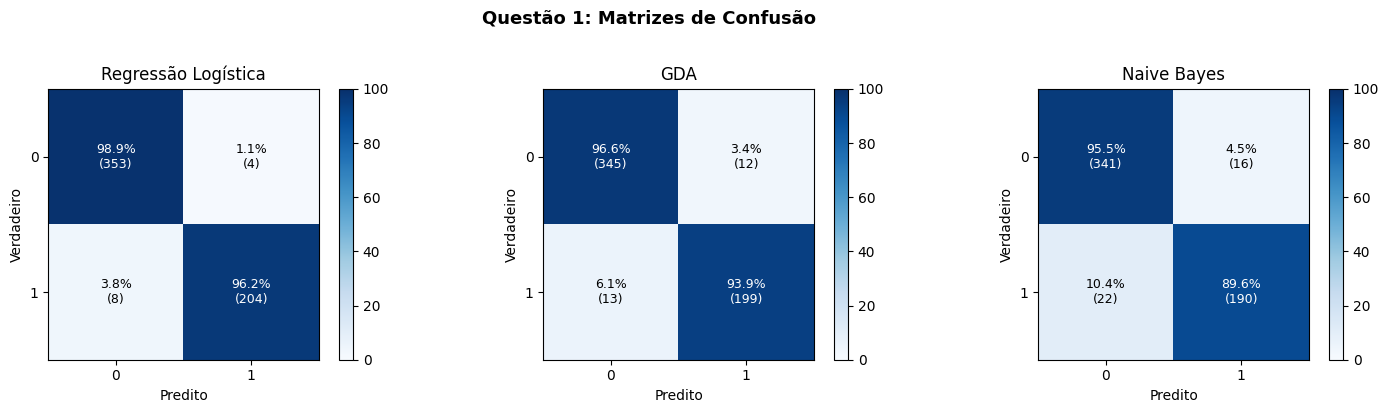

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_cm(confusion_matrix(yt_lr, yp_lr, np.unique(y1)), np.unique(y1), "Regressão Logística", axes[0])
plot_cm(confusion_matrix(yt_gd1, yp_gd1, np.unique(y1)), np.unique(y1), "GDA", axes[1])
plot_cm(confusion_matrix(yt_nb1, yp_nb1, np.unique(y1)), np.unique(y1), "Naive Bayes", axes[2])
plt.suptitle("Questão 1: Matrizes de Confusão", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Distribuição de Acurácia nos 10 Folds

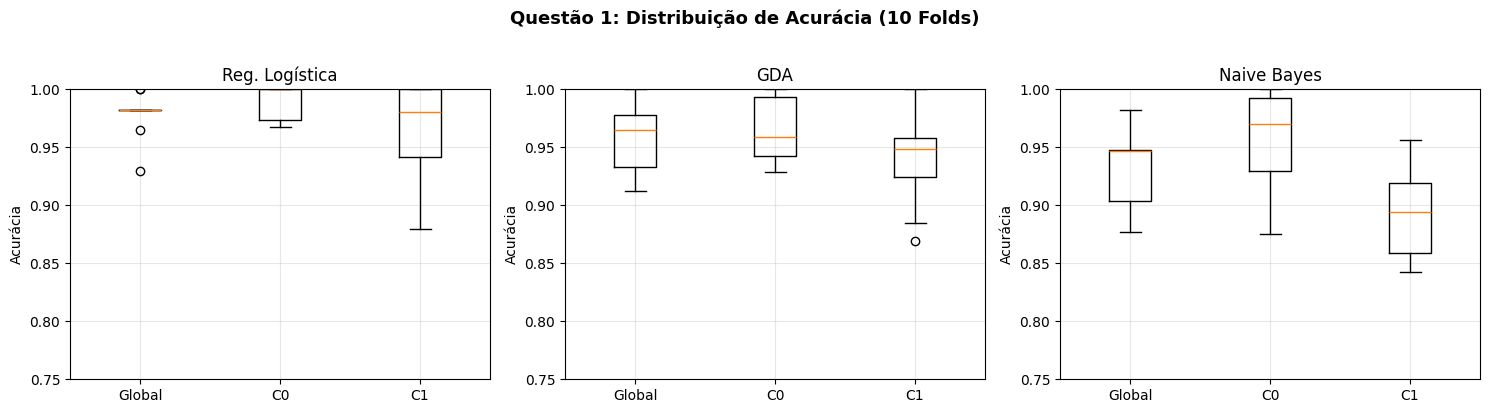

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (model, accs, accs_c) in enumerate(zip(models, [accs_lr, accs_gd1, accs_nb1], [accs_lr_c, accs_gd1_c, accs_nb1_c])):
    data_box = [accs] + [np.array(accs_c[c]) for c in sorted(accs_c.keys())]
    labels = ["Global"] + [f"C{int(c)}" for c in sorted(accs_c.keys())]
    axes[idx].boxplot(data_box, labels=labels)
    axes[idx].set_title(model)
    axes[idx].set_ylabel("Acurácia")
    axes[idx].set_ylim([0.75, 1.0])
    axes[idx].grid(True, alpha=0.3)
plt.suptitle("Questão 1: Distribuição de Acurácia (10 Folds)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Questão 2 - Classificação de Veículos (Multiclasse)

**Dataset:** `vehicle.csv` — 846 amostras, 18 atributos, 4 classes (bus, opel, saab, van).

Avaliação em validação cruzada (10 folds) dos classificadores multiclasse:
- Regressão Softmax (GD)
- Análise do Discriminante Gaussiano
- Naive Bayes Gaussiano

### Carregamento dos Dados

In [14]:
data2 = np.genfromtxt("./data/vehicle.csv", delimiter=",")
X2 = data2[:, :-1]
y2 = data2[:, -1].astype(int)

print(f"Amostras: {X2.shape[0]} | Features: {X2.shape[1]}")
values2, counts2 = np.unique(y2, return_counts=True)
for v, c in zip(values2, counts2):
    print(f"Classe {int(v)}: {int(c)} ({c / X2.shape[0] * 100:.1f}%)")

Amostras: 846 | Features: 18
Classe 0: 218 (25.8%)
Classe 1: 212 (25.1%)
Classe 2: 217 (25.7%)
Classe 3: 199 (23.5%)


### Treinamento e Avaliação (10-Fold CV)

In [15]:
num_classes_q2 = len(np.unique(y2))

def softmax_fit(X, y):
    return softmax_regression_gd(X, y, num_classes_q2)

np.random.seed(42)
accs_sm, accs_sm_c, yt_sm, yp_sm = evaluate_kfold(X2, y2, softmax_fit, predict_softmax)
accs_gd2, accs_gd2_c, yt_gd2, yp_gd2 = evaluate_kfold(X2, y2, gaussian_discriminant, predict_gda)
accs_nb2, accs_nb2_c, yt_nb2, yp_nb2 = evaluate_kfold(X2, y2, naive_bayes_gaussian, predict_nb)

### Resultados: Acurácia Global e por Classe

In [16]:
results_q2 = {
    "Regressão Softmax": (accs_sm, accs_sm_c),
    "GDA": (accs_gd2, accs_gd2_c),
    "Naive Bayes": (accs_nb2, accs_nb2_c)
}
print_summary("QUESTÃO 2 - CLASSIFICAÇÃO DE VEÍCULOS", results_q2)

QUESTÃO 2 - CLASSIFICAÇÃO DE VEÍCULOS
------------------------------------------------------------
Modelo                   Acurácia Global       
------------------------------------------------------------
Regressão Softmax        0.7623 ± 0.0410
GDA                      0.8535 ± 0.0340
Naive Bayes              0.4597 ± 0.0467

Modelo                   Classe 0              Classe 1              Classe 2              Classe 3              
------------------------------------------------------------
Regressão Softmax        0.9057 ± 0.0336  0.5979 ± 0.1015  0.6074 ± 0.0999  0.9619 ± 0.0527  
GDA                      0.9783 ± 0.0292  0.7459 ± 0.0414  0.7000 ± 0.1183  0.9909 ± 0.0182  
Naive Bayes              0.1602 ± 0.0862  0.4126 ± 0.1226  0.4206 ± 0.1034  0.8676 ± 0.0953  



### Comparação de Modelos

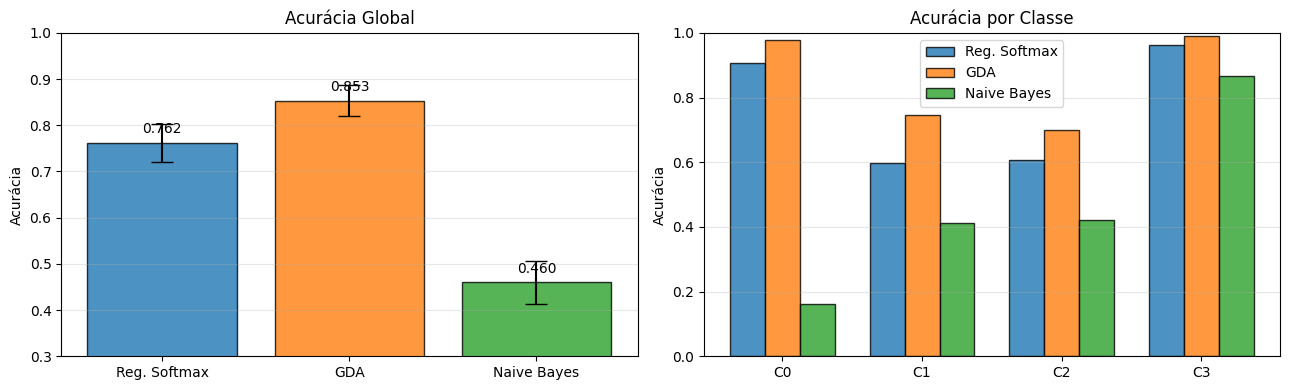

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
models2 = ["Reg. Softmax", "GDA", "Naive Bayes"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
width = 0.25
means2 = [np.mean(accs_sm), np.mean(accs_gd2), np.mean(accs_nb2)]
stds2 = [np.std(accs_sm), np.std(accs_gd2), np.std(accs_nb2)]

axes[0].bar(models2, means2, yerr=stds2, capsize=8, color=colors, alpha=0.8, edgecolor="black")
axes[0].set_ylabel("Acurácia")
axes[0].set_ylim([0.3, 1.0])
axes[0].set_title("Acurácia Global")
axes[0].grid(True, alpha=0.3, axis="y")
for i, m in enumerate(means2):
    axes[0].text(i, m + 0.02, f"{m:.3f}", ha="center")

classes2 = sorted(np.unique(y2))
x = np.arange(len(classes2))
for i, (model, accs_c) in enumerate(zip(models2, [accs_sm_c, accs_gd2_c, accs_nb2_c])):
    means_c = [np.mean(accs_c[c]) for c in classes2]
    axes[1].bar(x + i * width, means_c, width, label=model, color=colors[i], alpha=0.8, edgecolor="black")
axes[1].set_xticks(x + width)
axes[1].set_xticklabels([f"C{c}" for c in classes2])
axes[1].set_ylabel("Acurácia")
axes[1].set_ylim([0.0, 1.0])
axes[1].set_title("Acurácia por Classe")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### Matrizes de Confusão

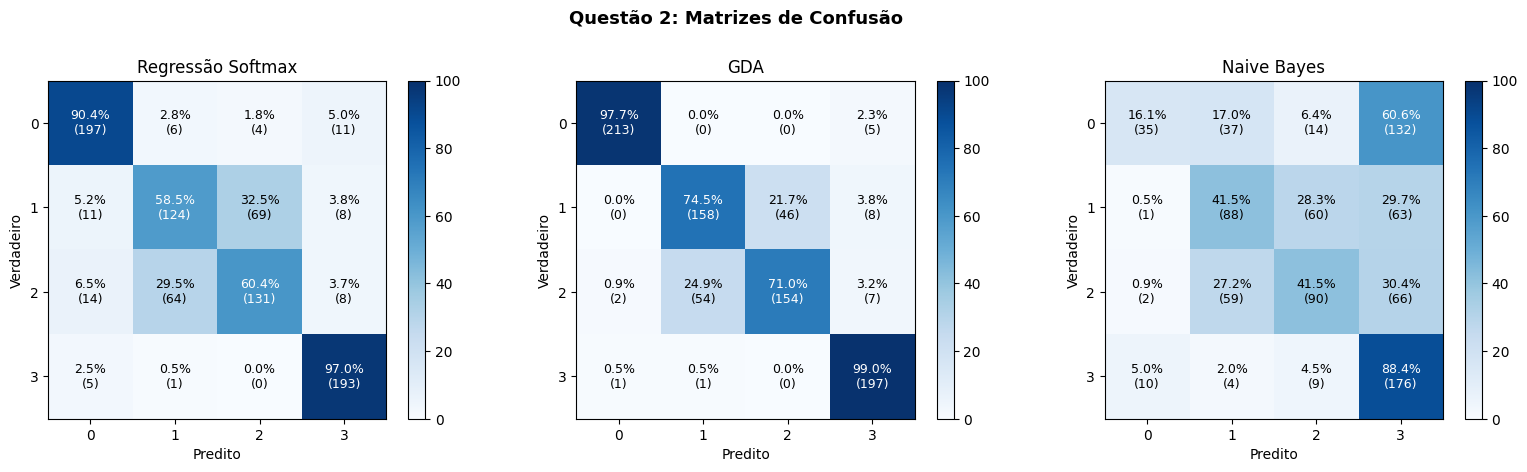

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_cm(confusion_matrix(yt_sm, yp_sm, np.unique(y2)), np.unique(y2), "Regressão Softmax", axes[0])
plot_cm(confusion_matrix(yt_gd2, yp_gd2, np.unique(y2)), np.unique(y2), "GDA", axes[1])
plot_cm(confusion_matrix(yt_nb2, yp_nb2, np.unique(y2)), np.unique(y2), "Naive Bayes", axes[2])
plt.suptitle("Questão 2: Matrizes de Confusão", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Distribuição de Acurácia nos 10 Folds

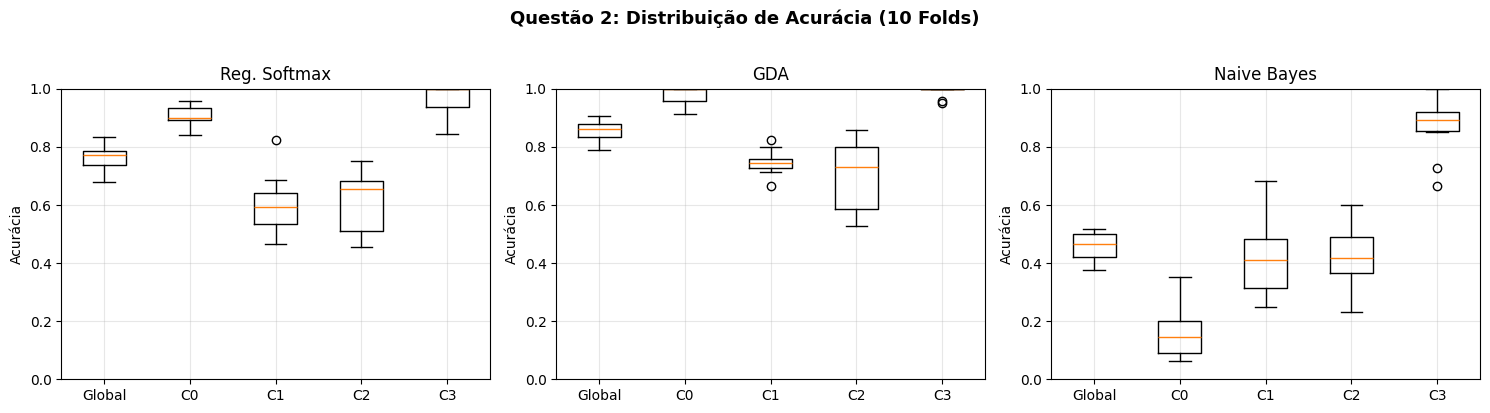

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (model, accs, accs_c) in enumerate(zip(models2, [accs_sm, accs_gd2, accs_nb2], [accs_sm_c, accs_gd2_c, accs_nb2_c])):
    data_box = [accs] + [np.array(accs_c[c]) for c in sorted(accs_c.keys())]
    labels = ["Global"] + [f"C{int(c)}" for c in sorted(accs_c.keys())]
    axes[idx].boxplot(data_box, labels=labels)
    axes[idx].set_title(model)
    axes[idx].set_ylabel("Acurácia")
    axes[idx].set_ylim([0.0, 1.0])
    axes[idx].grid(True, alpha=0.3)
plt.suptitle("Questão 2: Distribuição de Acurácia (10 Folds)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()